#### Question 6: Adveserial Auto encoders


In [18]:
model_name = 'adv_AE'
#Adversarial Autoencoder
import os
import tqdm
import torch
import numpy as np
import torch.nn as nn
import matplotlib.pyplot as plt
from torchvision.utils import make_grid
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
import torchvision.transforms as transforms
from torchvision.utils import save_image
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [19]:
# Data loading
path = os.path.join(os.getcwd(), 'data','butterfly')

MEAN = torch.tensor([0.47998455, 0.46537864, 0.33653912]) # After Calculation, Mean is directly given to the code.
STD = torch.tensor([0.22608626, 0.22103393, 0.21348171])


image_size = 128
batch_size = 128
workers = 12
n_channels = 3
latent_dim = 128 # [32, 64, 128, 256, 512]
lr =0.001
transform = transforms.Compose([
    transforms.Resize(image_size),
    transforms.CenterCrop(image_size),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD)
])

train_data = ImageFolder(path, transform=transform)
loader = DataLoader(train_data, batch_size=batch_size, shuffle=True, num_workers=workers)

classes = train_data.classes

In [20]:
class Encoder(nn.Module):
    def __init__(self, latent_dim):
        super(Encoder, self).__init__()
        self.latent_dim = latent_dim
        self.encoder = nn.Sequential(
            nn.Conv2d(n_channels, 32, 4, 2, 1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(32, 64, 4, 2, 1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(64, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(128, 256, 4, 2, 1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Flatten(),
            nn.Linear(256*8*8, latent_dim)
        )
    def forward(self, x):
        return self.encoder(x)
    
class Decoder(nn.Module):
    def __init__(self, latent_dim):
        super(Decoder, self).__init__()
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 256*8*8),
            nn.ReLU(inplace=True),
            nn.Unflatten(1, (256, 8, 8)),
            nn.ConvTranspose2d(256, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(128, 64, 4, 2, 1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(64, 32, 4, 2, 1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(32, n_channels, 4, 2, 1),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.decoder(x)*0.5+0.5

class Discriminator(nn.Module):
    def __init__(self, latent_dim):
        super(Discriminator, self).__init__()
        self.discriminator = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(256, 128),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(128, 1),
            nn.Sigmoid()
        )
    def forward(self, x):
        x = x + torch.randn_like(x)*0.005
        return self.discriminator(x)
    
class Adv_AE(nn.Module):
    def __init__(self, latent_dim):
        super(Adv_AE, self).__init__()
        self.encoder = Encoder(latent_dim)
        self.decoder = Decoder(latent_dim)
        self.discriminator = Discriminator(latent_dim)
    def forward(self, x):
        z = self.encoder(x)
        x_hat = self.decoder(z)
        return x_hat, z
    
model = Adv_AE(latent_dim).to(device)
criterion_ae = nn.MSELoss()
criterion_d = nn.BCELoss()
optimizer_ae = torch.optim.Adam(model.parameters(), lr=lr)
optimizer_d = torch.optim.Adam(model.discriminator.parameters(), lr=lr)


In [21]:


for epoch in range(100):
    for i, (x, _) in enumerate(loader):
        x = x.to(device)
        x_hat, z = model(x)
        
        # Train Autoencoder first

        loss_ae = criterion_ae(x_hat, x)

        optimizer_ae.zero_grad()
        loss_ae.backward()
        optimizer_ae.step()

        # Train Discriminator
        z_fake = torch.randn(x.size(0), latent_dim).to(device) # fake latent from sampled normal distribution
        z_real = z.detach() # real latent from encoder

        y_real = model.discriminator(z_real)
        y_fake = model.discriminator(z_fake)

        loss_D = criterion_d(y_real, torch.zeros_like(y_real)) + criterion_d(y_fake, torch.ones_like(y_fake))

        optimizer_d.zero_grad()
        loss_D.backward()
        optimizer_d.step()

        if i % 100 == 0:
            print(f'Epoch [{epoch}/{100}], Step [{i}/{len(loader)}], Loss Discriminator: {loss_D.item()}, Loss Autoencoder: {loss_ae.item()}')

    if epoch % 15 == 0:
        save_image(x_hat, f'output/{model_name}/{epoch}.png', nrow=8, normalize=True)


Epoch [0/100], Step [0/51], Loss Discriminator: 1.3700096607208252, Loss Autoencoder: 2.0252151489257812
Epoch [1/100], Step [0/51], Loss Discriminator: 0.021485937759280205, Loss Autoencoder: 1.4975770711898804
Epoch [2/100], Step [0/51], Loss Discriminator: 0.0428311824798584, Loss Autoencoder: 1.4990208148956299
Epoch [3/100], Step [0/51], Loss Discriminator: 0.014705161564052105, Loss Autoencoder: 1.5489658117294312
Epoch [4/100], Step [0/51], Loss Discriminator: 0.008608000352978706, Loss Autoencoder: 1.4688546657562256
Epoch [5/100], Step [0/51], Loss Discriminator: 0.06857269257307053, Loss Autoencoder: 1.46609628200531
Epoch [6/100], Step [0/51], Loss Discriminator: 0.18065382540225983, Loss Autoencoder: 1.5823323726654053
Epoch [7/100], Step [0/51], Loss Discriminator: 0.0042342678643763065, Loss Autoencoder: 1.4580714702606201
Epoch [8/100], Step [0/51], Loss Discriminator: 0.00783917773514986, Loss Autoencoder: 1.5027194023132324
Epoch [9/100], Step [0/51], Loss Discriminato

In [22]:
torch.save(model, f'adv_ae.pth')

Reconstructed images of adverserial auto encoder

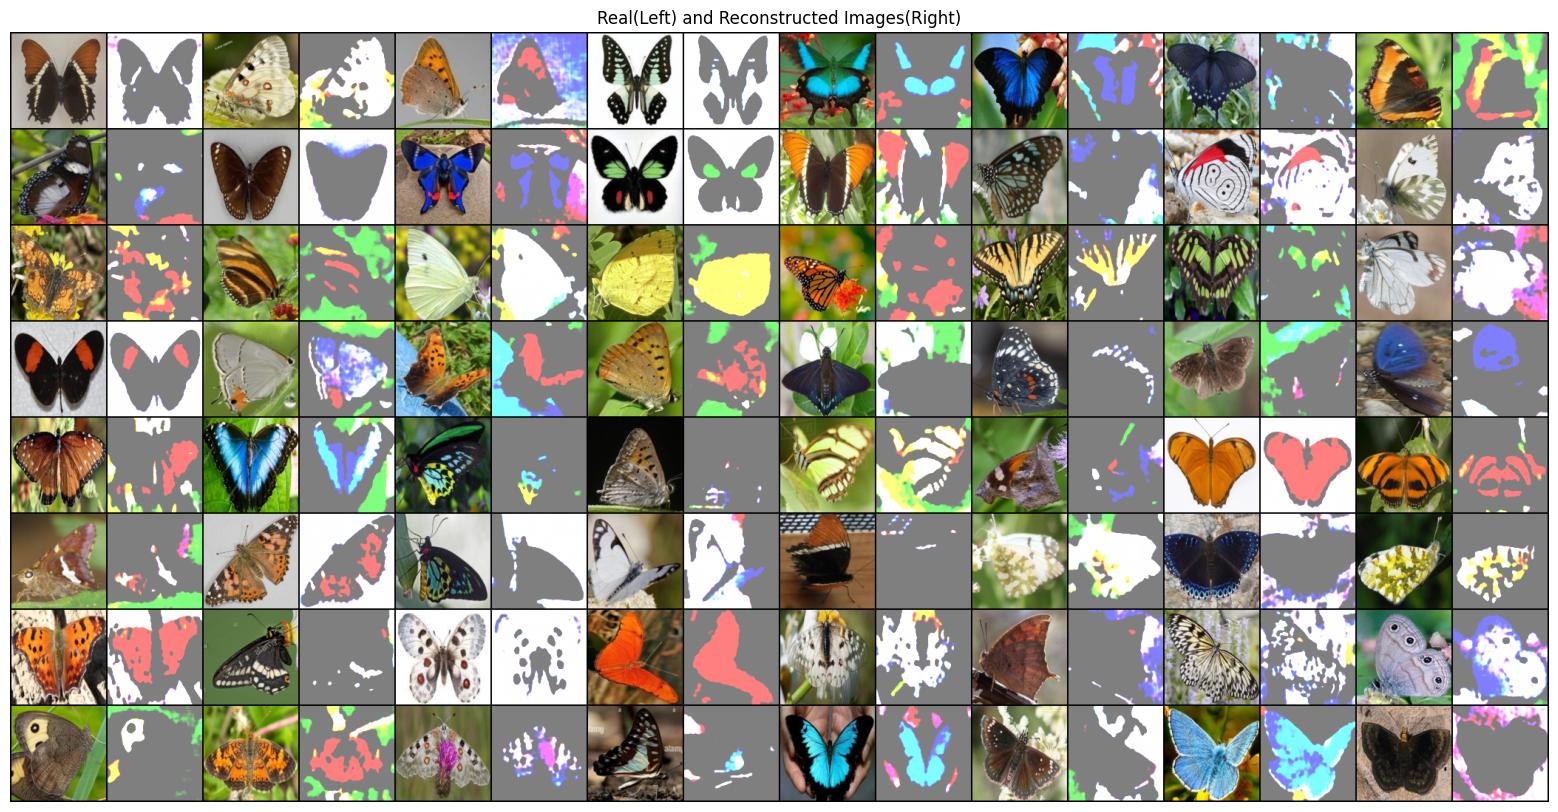

In [30]:
# Give real images to encoder and get reconstructed images from decoder
import random
# Load the VAE model
vae = torch.load(f'adv_ae.pth', weights_only=False)
vae.eval()
n_images = 64  # Number of images to display
img_list = []
rec_img_list = []

# Randomly select indices
indices = random.sample(range(len(train_data)), n_images)

# Process images
for idx in indices:
    img, _ = train_data[idx]
    img = img.unsqueeze(0).to(device)
    rec_img = vae(img)[0].clamp(0, 1)
    img_list.append(img.squeeze(0))
    rec_img_list.append(rec_img.squeeze(0))

# Combine real and reconstructed images
combined_images = []
for real_img, rec_img in zip(img_list, rec_img_list):
    real_img = real_img * STD[:, None, None].to(device) + MEAN[:, None, None].to(device)
    combined_images.append(real_img)
    combined_images.append(rec_img)

# Ensure all tensors are on the same device
combined_images = [img.to(device) for img in combined_images]

# Create a grid of images
combined_images = torch.stack(combined_images, dim=0)
grid_img = make_grid(combined_images, nrow=16, padding=2)

# Plot the images
plt.figure(figsize=(20, 10))  # Adjust the width and height as needed
plt.title("Real(Left) and Reconstructed Images(Right)")
plt.axis("off")
plt.imshow(grid_img.cpu().clamp(0, 1).permute(1, 2, 0).numpy())
plt.show()

generated images of adverserial auto encoders

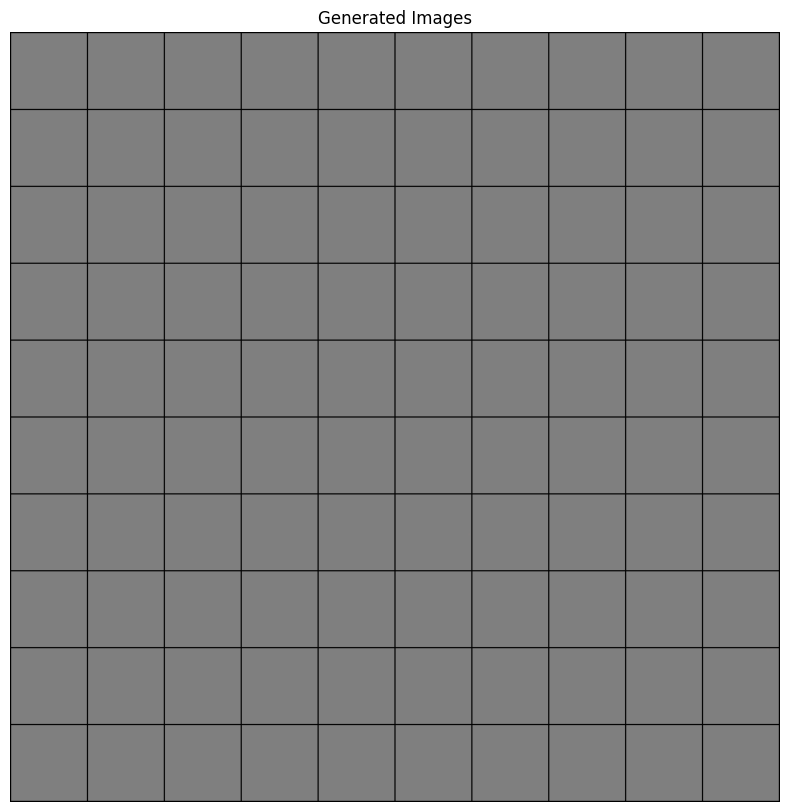

In [24]:
# Give real images to encoder and get reconstructed images from decoder
vae = torch.load(f'adv_ae.pth',weights_only=False)
vae.eval()
n_images = 100
img_list = []
for i in range(n_images):
    noise = torch.randn(1, latent_dim).to(device)
    rec_img = vae.decoder(noise).clamp(0, 1)
    img_list.append(rec_img)
img_list = torch.cat(img_list, dim=0)
plt.figure(figsize=(10,10))
plt.title("Generated Images")
plt.axis('off')
plt.imshow(make_grid(img_list,padding=2, nrow=10).cpu().permute(1, 2, 0))
plt.show()

We couldn't generate images using decoder.

Fid calculation of AAE

In [25]:
# FID Computation for 1000 images generated using VAE
vae = torch.load(f'adv_ae.pth',weights_only=False).to(device)
vae.eval()
n_images = 1000
with torch.no_grad():
    fake_images = []
        # sample 1000 images from the noise
    for i in range(1000):
        noise = torch.randn(1, latent_dim).to(device)
        img = vae.decoder(noise).view(1,3,128,128).clamp(0, 1)
        fake_images.append(img)
    fake_images = torch.cat(fake_images, dim=0)
    # 1000 real fake_images in tensor format
    real_images = []
    # sample 1000 images from the training set
    for i in range(1000):
        img = train_data[i][0].clamp(0,1).to(device)
        real_images.append(img)

    from pytorch_fid import fid_score
    from torcheval.metrics import FrechetInceptionDistance

    fid_metric = FrechetInceptionDistance()
    real_images = torch.stack(real_images)
    fake_images = torch.tensor(fake_images)
    # Update the FID metric with real and generated images
    fid_metric.update(real_images, is_real=True)
    fid_metric.update(fake_images, is_real=False)

    # Compute the FID score
    fid_score = fid_metric.compute()
    print(f'FID Score for {n_images} images: {fid_score}')


C:\Users\Shivam\AppData\Local\Temp\ipykernel_5784\613253244.py:25: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  fake_images = torch.tensor(fake_images)


FID Score for 1000 images: 403.8470153808594
